# 实验二：说话人嵌入空间与扰动分析（35%）

实验一中，我们已经学会了如何把一段语音输入 ECAPA-TDNN，并得到 speaker embedding。实验二将进一步观察这些 embedding 在一个小型 AISHELL 数据集（AISHELL的子集）中的分布。

Speaker embedding 是说话人识别模型从一段语音中提取出的固定长度向量，用于表征该语音中与说话人身份相关的声学特征。

每条语音会经过预训练的 ECAPA-TDNN 模型，被映射为一个 192 维向量。所有语音的 embeddings 共同构成一个高维向量空间，我们称之为 speaker embedding 空间。

在理想情况下，这个空间具有以下性质：
- 同一说话人的不同语音，其 embeddings 应该彼此接近；
- 不同说话人的语音，其 embeddings 应该相对远离；
- embedding 中应主要保留与说话人身份相关的信息，同时尽量减弱文本内容、语速、音量、噪声和录音条件等无关因素的影响。

需要注意的是，speaker embedding 并不是说话人身份的“纯净表示”。它仍然可能包含性别、年龄、口音、录音通道、背景噪声、语音内容等信息。因此，embedding 空间中的聚类结构既可能反映说话人身份，也可能受到其他声学或数据因素的影响。

由于 192 维空间无法直接可视化，本实验使用 t-SNE 将 embeddings 投影到二维平面上。t-SNE 可以帮助我们观察局部邻近关系和聚类趋势，但二维图中的全局距离、簇间距离和方向不能被直接解释为原始高维空间中的真实几何关系。

在本实验中，我们将通过 t-SNE 观察 clean speech embeddings 的分布，并进一步分析音频扰动对 speaker embeddings 的影响。

实验目标：
- 批量提取纯净语音的 speaker embeddings；
- 使用 t-SNE 可视化 embedding；
- 对语音加入噪声或通道扰动；
- 再次提取 embedding，能够定性定量地比较扰动前后的变化。

## 使用到的metadata
- metadata/speakers.csv：说话人元数据。
- metadata/utterances.csv：每一行对应一条被选中的语音。

In [1]:
# 读取 metadata

from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path(".").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "aishell_mini"
OUT_DIR = PROJECT_ROOT / "outputs"

speakers = pd.read_csv(DATA_DIR / "metadata" / "speakers.csv")
utts = pd.read_csv(DATA_DIR / "metadata" / "utterances.csv")

display(speakers.head())
display(utts.head())

print("num speakers:", speakers["spk_id"].nunique())
print("num utterances:", len(utts))
print('------')
print("gender distribution:")
print(speakers["gender"].value_counts())
print('------')
print("duration statistics:")
print(utts["duration_sec"].describe())

,spk_id,gender,is_known,num_selected_utts,num_total_valid_utts
0,S0251,0,1,24,322
1,S0096,0,1,24,338
2,S0160,1,1,24,353
3,S0166,1,1,24,350
4,S0248,0,1,24,330


,utt_id,spk_id,path,duration_sec,sample_rate,num_channels,text_id,transcript,source_split,gender,role
0,BAC009S0251W0458,S0251,wav/S0251/BAC009S0251W0458.wav,3.169938,16000,1,W0458,但 有 胶带 贴 过 的 痕迹,train,0,enroll
1,BAC009S0251W0349,S0251,wav/S0251/BAC009S0251W0349.wav,4.274938,16000,1,W0349,胡 丽梅 赛后 接受 采访 时 说,train,0,enroll
2,BAC009S0251W0248,S0251,wav/S0251/BAC009S0251W0248.wav,7.363062,16000,1,W0248,可以 分别 参股 二家 基金 公司 其中 控股 不 得超 过 一 家,train,0,enroll
3,BAC009S0251W0448,S0251,wav/S0251/BAC009S0251W0448.wav,7.376938,16000,1,W0448,北二 环西 直 门桥 通往 西直 门外 大街 的 匝道 桥 上,train,0,identification_test
4,BAC009S0251W0491,S0251,wav/S0251/BAC009S0251W0491.wav,5.927000,16000,1,W0491,北京 三里 屯 男子 持 刀伤 人 女子 胸部 中 刀 倒地,train,0,identification_test


num speakers: 20
num utterances: 400
------
gender distribution:
gender
1    11
0     9
Name: count, dtype: int64
------
duration statistics:
count    400.000000
mean       4.484213
std        1.339480
min        2.083938
25%        3.395703
50%        4.275531
75%        5.290000
max        7.980000
Name: duration_sec, dtype: float64


In [2]:
# 检查每个 speaker 的 utterance 数量
spk_counts = utts.groupby("spk_id").size().reset_index(name="num_utts")
spk_counts = spk_counts.merge(speakers, on="spk_id", how="left")
display(spk_counts.sort_values("num_utts"))

,spk_id,num_utts,gender,is_known,num_selected_utts,num_total_valid_utts
19,S0758,4,1,0,4,361
1,S0049,4,0,0,4,342
3,S0105,4,0,0,4,326
4,S0114,4,0,0,4,349
17,S0731,24,0,1,24,353
16,S0722,24,0,1,24,352
15,S0655,24,1,1,24,353
14,S0517,24,1,1,24,359
13,S0340,24,1,1,24,366
12,S0251,24,0,1,24,322


In [3]:
# 加载 CN-Celeb ECAPA-TDNN 预训练模型
import torch
import torchaudio
import torch.nn.functional as F
from speechbrain.inference.speaker import EncoderClassifier
from speechbrain.utils.fetching import LocalStrategy

# 兼容性补丁: 让 SpeechBrain 1.1.0 的 torch.amp.custom_fwd(device_type=...) 在 torch 2.1.2 下可用
import functools
def _install_amp_shim():
    _cuda_fwd, _cuda_bwd = torch.cuda.amp.custom_fwd, torch.cuda.amp.custom_bwd
    def custom_fwd(fwd=None, *, device_type=None, cast_inputs=None):
        if fwd is None:
            return functools.partial(custom_fwd, device_type=device_type, cast_inputs=cast_inputs)
        return fwd if device_type == "cpu" else _cuda_fwd(fwd, cast_inputs=cast_inputs)
    def custom_bwd(bwd=None, *, device_type=None):
        if bwd is None:
            return functools.partial(custom_bwd, device_type=device_type)
        return bwd if device_type == "cpu" else _cuda_bwd(bwd)
    torch.amp.custom_fwd, torch.amp.custom_bwd = custom_fwd, custom_bwd
_install_amp_shim()

device = "cuda" if torch.cuda.is_available() else "cpu"
CKPT_DIR = PROJECT_ROOT / "ckpt" / "spkrec-ecapa-cnceleb"

classifier = EncoderClassifier.from_hparams(
    source=str(CKPT_DIR),
    savedir=str(CKPT_DIR),
    run_opts={"device": device},
    local_strategy=LocalStrategy.NO_LINK,
)

@torch.no_grad()
def extract_embedding_from_path(path):
    wav, sr = torchaudio.load(path)
    wavs = wav.squeeze(0).unsqueeze(0).to(device)
    emb = classifier.encode_batch(wavs).squeeze().detach().cpu()
    emb = F.normalize(emb, dim=0)
    return emb


Could not parse CUDA device string 'cuda': not enough values to unpack (expected 2, got 1). Falling back to device 0.


In [4]:
# 批量提取 clean embeddings
from tqdm.auto import tqdm

emb_rows = []
emb_list = []

for _, row in tqdm(utts.iterrows(), total=len(utts)):
    wav_path = DATA_DIR / row["path"]
    emb = extract_embedding_from_path(wav_path)

    emb_list.append(emb.numpy())
    emb_rows.append({
        "utt_id": row["utt_id"],
        "spk_id": row["spk_id"],
        "path": row["path"],
        "condition": "clean",
    })

emb_arr = np.stack(emb_list, axis=0)
emb_meta = pd.DataFrame(emb_rows)

np.save(OUT_DIR / "embeddings" / "embeddings_clean.npy", emb_arr)
emb_meta.to_csv(OUT_DIR / "embeddings" / "embeddings_clean_meta.csv", index=False)

print("embedding array:", emb_arr.shape)
display(emb_meta.head())

C:\Users\admin\.conda\envs\speechbrain\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 1/400 [00:00<04:37,  1.44it/s]

  1%|          | 3/400 [00:00<01:39,  3.99it/s]

  1%|▏         | 5/400 [00:01<01:05,  6.05it/s]

...

 99%|█████████▉| 396/400 [00:31<00:00, 23.59it/s]

100%|█████████▉| 399/400 [00:31<00:00, 24.14it/s]

100%|██████████| 400/400 [00:31<00:00, 12.61it/s]

embedding array: (400, 192)


,utt_id,spk_id,path,condition
0,BAC009S0251W0458,S0251,wav/S0251/BAC009S0251W0458.wav,clean
1,BAC009S0251W0349,S0251,wav/S0251/BAC009S0251W0349.wav,clean
2,BAC009S0251W0248,S0251,wav/S0251/BAC009S0251W0248.wav,clean
3,BAC009S0251W0448,S0251,wav/S0251/BAC009S0251W0448.wav,clean
4,BAC009S0251W0491,S0251,wav/S0251/BAC009S0251W0491.wav,clean


In [5]:
# 合并 speaker metadata
emb_meta_merged = emb_meta.merge(speakers, on="spk_id", how="left")
display(emb_meta_merged.head())

,utt_id,spk_id,path,condition,gender,is_known,num_selected_utts,num_total_valid_utts
0,BAC009S0251W0458,S0251,wav/S0251/BAC009S0251W0458.wav,clean,0,1,24,322
1,BAC009S0251W0349,S0251,wav/S0251/BAC009S0251W0349.wav,clean,0,1,24,322
2,BAC009S0251W0248,S0251,wav/S0251/BAC009S0251W0248.wav,clean,0,1,24,322
3,BAC009S0251W0448,S0251,wav/S0251/BAC009S0251W0448.wav,clean,0,1,24,322
4,BAC009S0251W0491,S0251,wav/S0251/BAC009S0251W0491.wav,clean,0,1,24,322


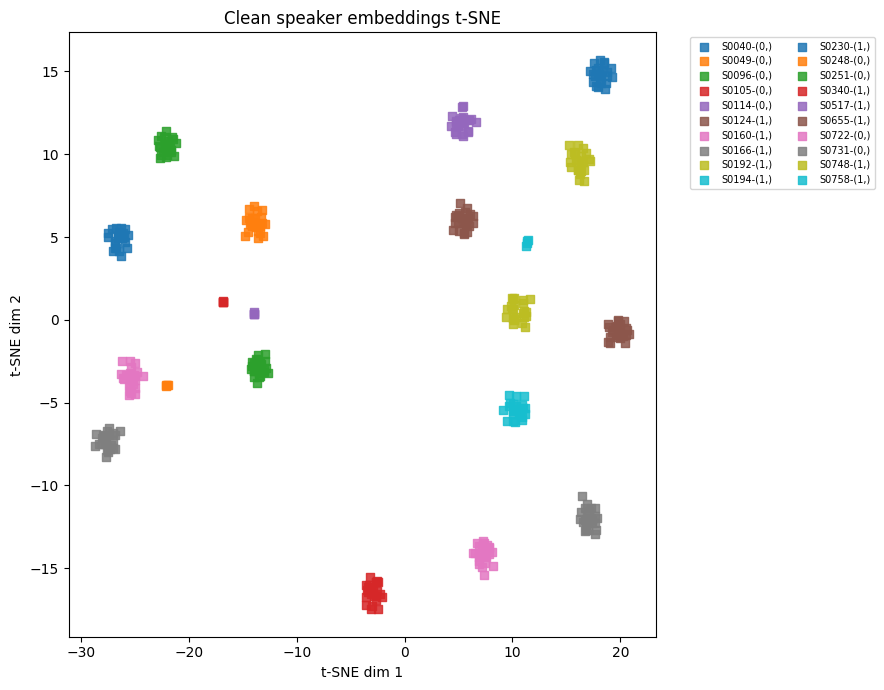

In [6]:
# t-SNE 可视化函数
# 颜色区分个体、形状区分性别
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def plot_tsne(embeddings, meta, title, out_path):
    n = embeddings.shape[0]
    perplexity = min(30, max(5, (n - 1) // 3))

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=42,
    )
    xy = tsne.fit_transform(embeddings)

    meta = meta.copy()
    meta["x"] = xy[:, 0]
    meta["y"] = xy[:, 1]

    spk_ids = sorted(meta["spk_id"].unique())
    gender_markers = {0: "o", 1: "^", "0": "o", "1": "^"}
    has_multiple_conditions = "condition" in meta.columns and meta["condition"].nunique() > 1

    plt.figure(figsize=(9, 7))

    for spk_id in spk_ids:
        sub_spk = meta[meta["spk_id"] == spk_id]
        group_cols = ["gender", "condition"] if has_multiple_conditions else ["gender"]
        for group_key, sub in sub_spk.groupby(group_cols):
            gender = group_key[0] if has_multiple_conditions else group_key
            condition = group_key[1] if has_multiple_conditions else "clean"
            marker = gender_markers.get(gender, "s")
            alpha = 0.85 if condition == "clean" else 0.35
            gender_name = "Male" if str(gender) == "0" else "Female" if str(gender) == "1" else str(gender)
            label = f"{spk_id}-{gender_name}" if not has_multiple_conditions else f"{spk_id}-{gender_name}-{condition}"
            plt.scatter(
                sub["x"],
                sub["y"],
                marker=marker,
                label=label,
                alpha=alpha,
            )

    plt.title(title)
    plt.xlabel("t-SNE dim 1")
    plt.ylabel("t-SNE dim 2")
    plt.legend(fontsize=7, ncol=2, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()

    return meta

tsne_clean_meta = plot_tsne(
    emb_arr,
    emb_meta_merged,
    "Clean speaker embeddings t-SNE",
    OUT_DIR / "figures" / "tsne_clean.png",
)

## 给音频添加扰动

In [7]:
# 定义扰动函数一：加噪声
def add_white_noise_snr(wav, snr_db):
    noise = torch.randn_like(wav)

    wav_power = (wav ** 2).mean()
    noise_power = (noise ** 2).mean()

    scale = torch.sqrt(wav_power / (noise_power * (10 ** (snr_db / 10))))
    noisy = wav + scale * noise
    noisy = noisy / (noisy.abs().max() + 1e-8)

    return noisy

# 定义扰动函数二：通道模拟
def simulate_8k_channel(wav):
    down = torchaudio.transforms.Resample(16000, 8000)(wav)
    up = torchaudio.transforms.Resample(8000, 16000)(down)
    up = up / (up.abs().max() + 1e-8)
    return up

## 可选扰动

除白噪声和 8k 通道模拟外，你可以尝试以下扰动：

1. MUSAN noise：真实噪声、音乐、背景说话人；
2. RIR：房间混响；
3. codec：压缩编码造成的失真；
4. time stretching：语速变化；
5. pitch shifting：基频变化。

In [8]:
# 生成增强音频
# 固定随机种子, 保证白噪声可复现
torch.manual_seed(42)

AUG_DIR = DATA_DIR / "augmented"
AUG_DIR.mkdir(parents=True, exist_ok=True)

aug_rows = []

for _, row in tqdm(utts.iterrows(), total=len(utts)):
    wav_path = DATA_DIR / row["path"]
    wav, sr = torchaudio.load(wav_path)

    # noise
    noisy = add_white_noise_snr(wav, snr_db=10)
    noisy_rel = f"augmented/noise_snr10/{row['spk_id']}/{row['utt_id']}_noise10.wav"
    noisy_abs = DATA_DIR / noisy_rel
    noisy_abs.parent.mkdir(parents=True, exist_ok=True)
    torchaudio.save(str(noisy_abs), noisy.cpu(), 16000)

    aug_rows.append({
        "utt_id": row["utt_id"] + "_noise10",
        "orig_utt_id": row["utt_id"],
        "spk_id": row["spk_id"],
        "path": noisy_rel,
        "condition": "noise_snr10",
    })

    # channel
    ch = simulate_8k_channel(wav)
    ch_rel = f"augmented/channel_8k/{row['spk_id']}/{row['utt_id']}_ch8k.wav"
    ch_abs = DATA_DIR / ch_rel
    ch_abs.parent.mkdir(parents=True, exist_ok=True)
    torchaudio.save(str(ch_abs), ch.cpu(), 16000)

    aug_rows.append({
        "utt_id": row["utt_id"] + "_ch8k",
        "orig_utt_id": row["utt_id"],
        "spk_id": row["spk_id"],
        "path": ch_rel,
        "condition": "channel_8k",
    })

aug_df = pd.DataFrame(aug_rows)
aug_df = aug_df.merge(speakers, on="spk_id", how="left")

display(aug_df.head())
aug_df.to_csv(DATA_DIR / "metadata" / "augmentations.csv", index=False)

  0%|          | 0/400 [00:00<?, ?it/s]

  1%|          | 3/400 [00:00<00:13, 29.77it/s]

  2%|▏         | 9/400 [00:00<00:08, 44.21it/s]

  4%|▍         | 15/400 [00:00<00:07, 50.27it/s]

  6%|▌         | 22/400 [00:00<00:06, 56.67it/s]

...

 96%|█████████▌| 382/400 [00:05<00:00, 64.59it/s]

 97%|█████████▋| 389/400 [00:05<00:00, 62.66it/s]

 99%|█████████▉| 396/400 [00:05<00:00, 63.60it/s]

100%|██████████| 400/400 [00:06<00:00, 66.27it/s]

,utt_id,orig_utt_id,spk_id,path,condition,gender,is_known,num_selected_utts,num_total_valid_utts
0,BAC009S0251W0458_noise10,BAC009S0251W0458,S0251,augmented/noise_snr10/S0251/BAC009S0251W0458_n...,noise_snr10,0,1,24,322
1,BAC009S0251W0458_ch8k,BAC009S0251W0458,S0251,augmented/channel_8k/S0251/BAC009S0251W0458_ch...,channel_8k,0,1,24,322
2,BAC009S0251W0349_noise10,BAC009S0251W0349,S0251,augmented/noise_snr10/S0251/BAC009S0251W0349_n...,noise_snr10,0,1,24,322
3,BAC009S0251W0349_ch8k,BAC009S0251W0349,S0251,augmented/channel_8k/S0251/BAC009S0251W0349_ch...,channel_8k,0,1,24,322
4,BAC009S0251W0248_noise10,BAC009S0251W0248,S0251,augmented/noise_snr10/S0251/BAC009S0251W0248_n...,noise_snr10,0,1,24,322


In [9]:
# 批量提取 augmented embeddings
aug_embs = []
aug_meta_rows = []

for _, row in tqdm(aug_df.iterrows(), total=len(aug_df)):
    emb = extract_embedding_from_path(DATA_DIR / row["path"])
    aug_embs.append(emb.numpy())

    aug_meta_rows.append({
        "utt_id": row["utt_id"],
        "orig_utt_id": row["orig_utt_id"],
        "spk_id": row["spk_id"],
        "path": row["path"],
        "condition": row["condition"],
        "gender": row["gender"],
    })

aug_emb_arr = np.stack(aug_embs, axis=0)
aug_meta = pd.DataFrame(aug_meta_rows)

np.save(OUT_DIR / "embeddings" / "embeddings_augmented.npy", aug_emb_arr)
aug_meta.to_csv(OUT_DIR / "embeddings" / "embeddings_augmented_meta.csv", index=False)

print(aug_emb_arr.shape)
display(aug_meta.head())

  0%|          | 0/800 [00:00<?, ?it/s]

  0%|          | 4/800 [00:00<00:24, 33.08it/s]

  1%|          | 8/800 [00:00<00:22, 34.74it/s]

  2%|▏         | 12/800 [00:00<00:23, 33.23it/s]

  2%|▏         | 16/800 [00:00<00:24, 31.71it/s]

...

100%|█████████▉| 796/800 [00:45<00:00, 21.15it/s]

100%|█████████▉| 799/800 [00:45<00:00, 21.33it/s]

100%|██████████| 800/800 [00:45<00:00, 17.55it/s]

(800, 192)


,utt_id,orig_utt_id,spk_id,path,condition,gender
0,BAC009S0251W0458_noise10,BAC009S0251W0458,S0251,augmented/noise_snr10/S0251/BAC009S0251W0458_n...,noise_snr10,0
1,BAC009S0251W0458_ch8k,BAC009S0251W0458,S0251,augmented/channel_8k/S0251/BAC009S0251W0458_ch...,channel_8k,0
2,BAC009S0251W0349_noise10,BAC009S0251W0349,S0251,augmented/noise_snr10/S0251/BAC009S0251W0349_n...,noise_snr10,0
3,BAC009S0251W0349_ch8k,BAC009S0251W0349,S0251,augmented/channel_8k/S0251/BAC009S0251W0349_ch...,channel_8k,0
4,BAC009S0251W0248_noise10,BAC009S0251W0248,S0251,augmented/noise_snr10/S0251/BAC009S0251W0248_n...,noise_snr10,0


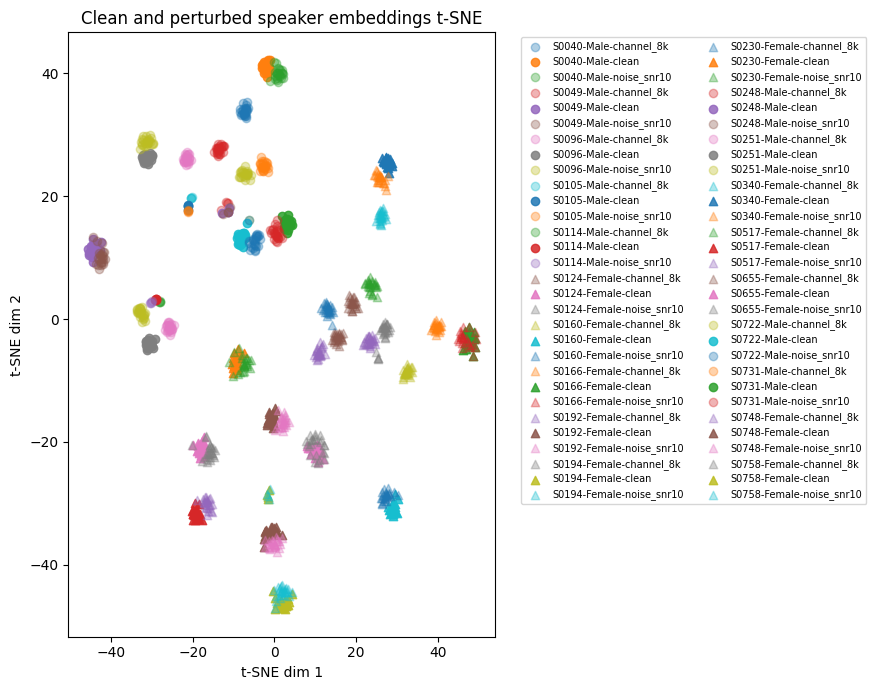

In [10]:
# clean + augmented t-SNE
combined_emb = np.concatenate([emb_arr, aug_emb_arr], axis=0)

clean_meta_for_plot = emb_meta_merged.copy()
clean_meta_for_plot["condition"] = "clean"
clean_meta_for_plot["orig_utt_id"] = clean_meta_for_plot["utt_id"]

combined_meta = pd.concat(
    [clean_meta_for_plot, aug_meta],
    ignore_index=True,
)

tsne_combined_meta = plot_tsne(
    combined_emb,
    combined_meta,
    "Clean and perturbed speaker embeddings t-SNE",
    OUT_DIR / "figures" / "tsne_clean_augmented_joint.png",
)

In [11]:
# 用 cosine 衡量扰动前后 embedding 漂移量（drift）
clean_lookup = {
    row["utt_id"]: emb_arr[i]
    for i, row in emb_meta.reset_index(drop=True).iterrows()
}

drift_rows = []

for i, row in aug_meta.reset_index(drop=True).iterrows():
    clean_emb = clean_lookup[row["orig_utt_id"]]
    aug_emb = aug_emb_arr[i]

    cos = float(np.dot(clean_emb, aug_emb) / (
        np.linalg.norm(clean_emb) * np.linalg.norm(aug_emb) + 1e-8
    ))

    drift_rows.append({
        "orig_utt_id": row["orig_utt_id"],
        "aug_utt_id": row["utt_id"],
        "spk_id": row["spk_id"],
        "gender": row["gender"],
        "condition": row["condition"],
        "cos_clean_aug": cos,
        "embedding_drift": 1 - cos,
    })

drift_df = pd.DataFrame(drift_rows)
display(drift_df.groupby("condition")[["cos_clean_aug", "embedding_drift"]].describe())

drift_df.to_csv(OUT_DIR / "scores" / "embedding_drift_clean_augmented.csv", index=False)

cos_clean_aug                                                    \
                    count      mean       std       min       25%       50%   
condition                                                                     
channel_8k          400.0  0.514031  0.096739  0.236640  0.446375  0.508724   
noise_snr10         400.0  0.703921  0.069247  0.468425  0.660189  0.713127   

                                embedding_drift                                \
                  75%       max           count      mean       std       min   
condition                                                                       
channel_8k   0.584270  0.766852           400.0  0.485969  0.096739  0.233148   
noise_snr10  0.756437  0.834327           400.0  0.296079  0.069247  0.165673   

                                                     
                  25%       50%       75%       max  
condition                                            
channel_8k   0.415730  0.491276  0.553625  0.763360  
noise_snr10  0.243563  0.286873  0.339811  0.531575

C:\Users\admin\AppData\Local\Temp\ipykernel_76728\1633081783.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=conditions)


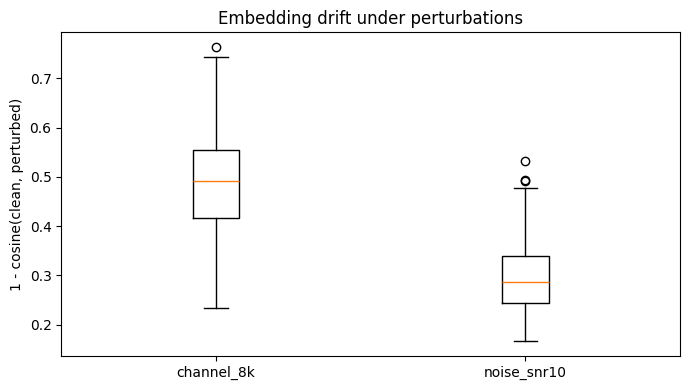

In [12]:
# 扰动影响箱线图
plt.figure(figsize=(7, 4))
conditions = sorted(drift_df["condition"].unique())
data = [drift_df[drift_df["condition"] == c]["embedding_drift"].values for c in conditions]

plt.boxplot(data, labels=conditions)
plt.ylabel("1 - cosine(clean, perturbed)")
plt.title("Embedding drift under perturbations")
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "embedding_drift_boxplot.png", dpi=150)
plt.show()

## 思考题 Q3 佐证实验：自实现一种扰动（变调 pitch shift）

白噪声与 8k 通道主要改变的是“信道/背景”，对说话人身份的破坏相对温和。这里额外实现一种**变调（pitch shift, +4 个半音）**扰动：它直接改变基频与共振峰位置，而基频/共振峰正是说话人身份的重要线索，因此预期它引起的 embedding 漂移会明显大于加噪与换通道。

In [13]:
# 自实现扰动: 变调 (pitch shift, +4 semitones)
from tqdm.auto import tqdm

pitch_shift = torchaudio.transforms.PitchShift(sample_rate=16000, n_steps=4)

pitch_embs, pitch_meta_rows = [], []
for _, row in tqdm(utts.iterrows(), total=len(utts)):
    wav, sr = torchaudio.load(DATA_DIR / row['path'])
    shifted = pitch_shift(wav)
    shifted = shifted / (shifted.abs().max() + 1e-8)
    wavs = shifted.squeeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = F.normalize(classifier.encode_batch(wavs).squeeze().detach().cpu(), dim=0)
    pitch_embs.append(emb.numpy())
    pitch_meta_rows.append({
        'utt_id': row['utt_id'] + '_pitch4', 'orig_utt_id': row['utt_id'],
        'spk_id': row['spk_id'], 'condition': 'pitch_shift',
    })

pitch_emb_arr = np.stack(pitch_embs, axis=0)
pitch_meta = pd.DataFrame(pitch_meta_rows)
print('pitch embeddings:', pitch_emb_arr.shape)

C:\Users\admin\.conda\envs\speechbrain\lib\site-packages\torch\nn\modules\lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 1/400 [00:01<10:54,  1.64s/it]

  0%|          | 2/400 [00:01<05:19,  1.25it/s]

  1%|          | 3/400 [00:02<03:39,  1.81it/s]

...

100%|█████████▉| 398/400 [01:23<00:00,  6.08it/s]

100%|█████████▉| 399/400 [01:23<00:00,  6.13it/s]

100%|██████████| 400/400 [01:23<00:00,  5.87it/s]

100%|██████████| 400/400 [01:23<00:00,  4.77it/s]

pitch embeddings: (400, 192)


,cos_clean_aug,embedding_drift
condition,,
channel_8k,0.514031,0.485969
noise_snr10,0.703921,0.296079
pitch_shift,0.214604,0.785396


C:\Users\admin\AppData\Local\Temp\ipykernel_76728\562418744.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=conds)


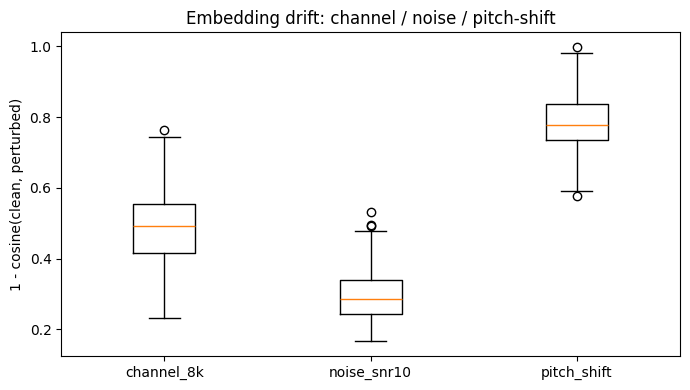

In [14]:
# 计算 pitch shift 的 drift, 并与 noise / channel 一起对比
clean_lookup = {row['utt_id']: emb_arr[i] for i, row in emb_meta.reset_index(drop=True).iterrows()}

pitch_drift_rows = []
for i, row in pitch_meta.reset_index(drop=True).iterrows():
    c = clean_lookup[row['orig_utt_id']]; a = pitch_emb_arr[i]
    cos = float(np.dot(c, a) / (np.linalg.norm(c) * np.linalg.norm(a) + 1e-8))
    pitch_drift_rows.append({'condition': 'pitch_shift', 'cos_clean_aug': cos, 'embedding_drift': 1 - cos})
pitch_drift_df = pd.DataFrame(pitch_drift_rows)

drift_all = pd.concat([
    drift_df[['condition', 'cos_clean_aug', 'embedding_drift']],
    pitch_drift_df,
], ignore_index=True)

summary = drift_all.groupby('condition')[['cos_clean_aug', 'embedding_drift']].mean()
display(summary)
drift_all.to_csv(OUT_DIR / 'scores' / 'embedding_drift_all.csv', index=False)

conds = ['channel_8k', 'noise_snr10', 'pitch_shift']
data = [drift_all[drift_all['condition'] == c]['embedding_drift'].values for c in conds]
plt.figure(figsize=(7, 4))
plt.boxplot(data, labels=conds)
plt.ylabel('1 - cosine(clean, perturbed)')
plt.title('Embedding drift: channel / noise / pitch-shift')
plt.tight_layout()
plt.savefig(OUT_DIR / 'figures' / 'embedding_drift_boxplot_all.png', dpi=150)
plt.show()

## 思考题
Q1. 为什么需要对两种 embeddings 联合拟合 t-SNE？

本实验同时可视化 clean embeddings 和 perturbed/noisy embeddings。
- 如果分别对 clean embeddings 和 noisy embeddings 各自运行一次 t-SNE，然后直接比较两张图中点的位置，这种比较是否严谨？为什么？

Q2. 性别和个体的聚类现象

本实验中，t-SNE 图使用 marker shape 表示 gender，使用 color 表示 speaker id。
请结合可视化结果回答：
- 如果观察到男声和女声在 t-SNE 空间中形成相对分离的两个大簇，这说明 speaker embedding 中可能包含哪些信息？
- 这种性别相关的聚类现象对说话人识别系统可能产生哪些影响？请分别从以下角度讨论：
    - 识别准确率：性别信息是否可能帮助模型区分说话人？它是否也可能使模型过度依赖非目标属性？
    - 算法公平性：不同性别群体的识别性能是否可能存在差异？这种差异可能带来什么问题？
    - 隐私保护：如果 speaker embedding 中包含性别等敏感属性信息，可能带来哪些隐私风险？

Q3. 扰动是否可能改变说话人身份？

**请尝试自己实现一种音频扰动方式。可以从可选扰动中选择一种，也可以自行设计一种新的扰动方法。**

完成后，请比较扰动前后模型提取到的 speaker embeddings，并分析：
- 这种扰动是否主要保持了说话人身份？
- 它是否明显改变了 embedding 的位置？
- 为什么这种扰动会带来当前观察到的影响量级？

Q4. 数据集 domain mismatch

本实验使用的模型训练于 CN-Celeb，但推理数据来自 AISHELL。请查阅 CN-Celeb 和 AISHELL 的录音场景或语料特点，并讨论：

- 二者都是中文语音，是否意味着不存在 domain mismatch？为什么？
- AISHELL 主要是较安静的朗读语音，这是否可能使本实验结果偏乐观？
- 如果将测试语音换成手机近场、会议远场或噪声环境下的语音，speaker embedding 的分布可能发生怎样的变化？可以基于你的观察和思考进行主观推测。